<a href="https://colab.research.google.com/github/jtsang2001/Smart-Grid-Load-Forecasting/blob/main/Thesis_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data

### Subtask:
Load the `energy_dataset_spain.csv` file into a pandas DataFrame for analysis.


In [1]:
import pandas as pd

df = pd.read_csv('/content/energy_dataset_spain.csv')

print("Displaying the first 5 rows:")
df.head()

Displaying the first 5 rows:


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


## Initial Data Overview

### Subtask:
Display the first few rows of the DataFrame, check data types, and identify the number of missing values to get an initial understanding of the dataset.


In [2]:
print("\nDataFrame Info:")
df.info()

print("\nNumber of missing values per column:")
print(df.isnull().sum())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-

## Handle Missing Values

###Remove some of columns that are completely missing values and fill in columns with a few missing values


In [3]:
df['time'] = pd.to_datetime(df['time'], utc=True)

# Identify columns with all null values or excessive missing values
# Based on df.isnull().sum() from previous step, 'generation hydro pumped storage aggregated' and 'forecast wind offshore eday ahead' have 35064 missing values (all null).
df = df.drop(columns=['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead'])

# For remaining numerical columns, apply forward fill and then backward fill
# Select only numeric columns for imputation
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    #Fill in values between
    df[col] = df[col].ffill()
    #Fill in values at the start and end
    df[col] = df[col].bfill()

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
time                                           0
generation biomass                             0
generation fossil brown coal/lignite           0
generation fossil coal-derived gas             0
generation fossil gas                          0
generation fossil hard coal                    0
generation fossil oil                          0
generation fossil oil shale                    0
generation fossil peat                         0
generation geothermal                          0
generation hydro pumped storage consumption    0
generation hydro run-of-river and poundage     0
generation hydro water reservoir               0
generation marine                              0
generation nuclear                             0
generation other                               0
generation other renewable                     0
generation solar                               0
generation waste                               0
generation wind offshore              

## Descriptive Statistics

Calculate and display descriptive statistics (mean, median, standard deviation, etc.) for key numerical columns in the dataset.


In [4]:
print("Descriptive statistics for numerical columns:")
print(df.select_dtypes(include=['number']).describe())

Descriptive statistics for numerical columns:
       generation biomass  generation fossil brown coal/lignite  \
count        35064.000000                          35064.000000   
mean           383.532797                            448.091918   
std             85.346455                            354.616732   
min              0.000000                              0.000000   
25%            333.000000                              0.000000   
50%            367.000000                            509.000000   
75%            433.000000                            757.000000   
max            592.000000                            999.000000   

       generation fossil coal-derived gas  generation fossil gas  \
count                             35064.0           35064.000000   
mean                                  0.0            5622.705653   
std                                   0.0            2201.557635   
min                                   0.0               0.000000   
25%       

## Time Series Visualization of Energy Data

### Generate line plots to visualize the trends of energy consumption, generation, and prices over time

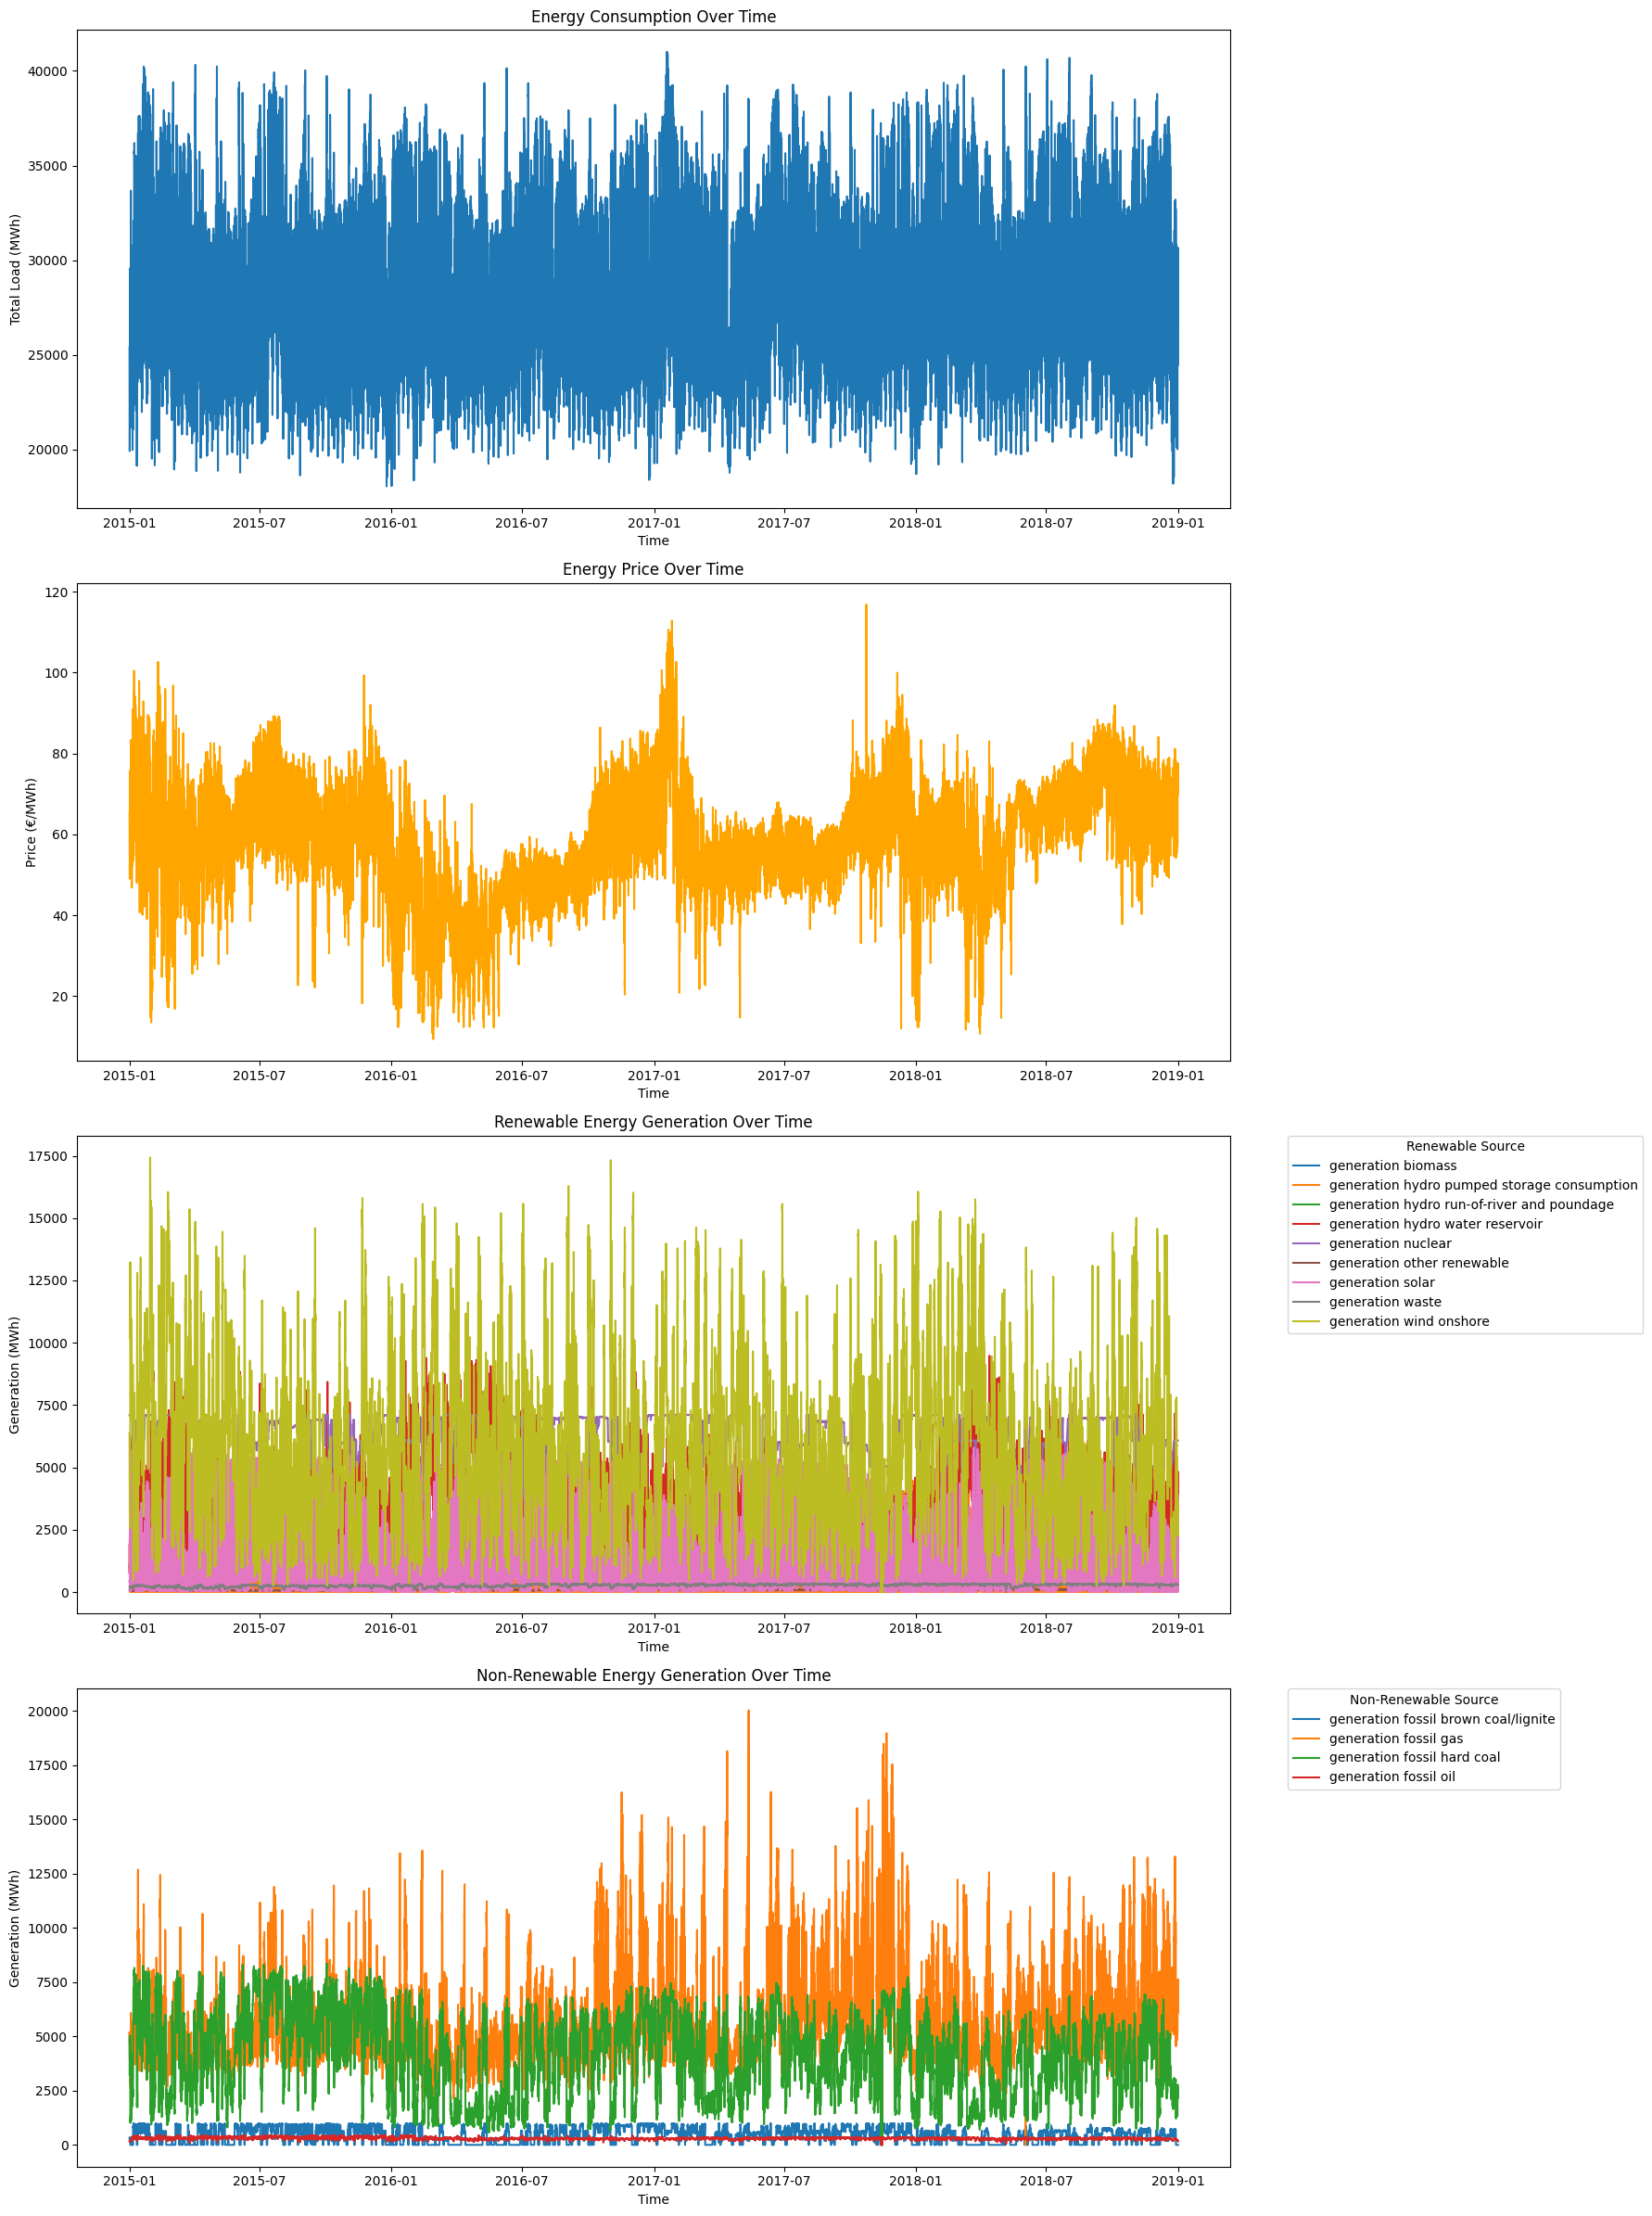

Generated line plots for energy consumption, price, and separated renewable and non-renewable generation sources with improved visibility.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the 'time' column as the DataFrame index
df_indexed = df.set_index('time')

# Create figure and axes for subplots, increasing the overall figure size
fig, axes = plt.subplots(4, 1, figsize=(18, 24), sharex=False) # Changed sharex to False

# Plot 1: Energy Consumption Over Time
sns.lineplot(data=df_indexed, x=df_indexed.index, y='total load actual', ax=axes[0])
axes[0].set_title('Energy Consumption Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Total Load (MWh)')

# Plot 2: Energy Price Over Time
sns.lineplot(data=df_indexed, x=df_indexed.index, y='price actual', ax=axes[1], color='orange')
axes[1].set_title('Energy Price Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Price (€/MWh)')

# Define renewable and non-renewable generation columns based on available data
renewable_generation_columns = [
    'generation biomass',
    'generation hydro pumped storage consumption',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation nuclear',
    'generation other renewable',
    'generation solar',
    'generation waste',
    'generation wind onshore'
]

non_renewable_generation_columns = [
    'generation fossil brown coal/lignite',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil'
]

# Filter out columns that don't exist in df or have zero mean
renewable_generation_columns = [col for col in renewable_generation_columns if col in df.columns and df[col].mean() != 0]
non_renewable_generation_columns = [col for col in non_renewable_generation_columns if col in df.columns and df[col].mean() != 0]

# Plot 3: Renewable Energy Generation Over Time
sns.lineplot(data=df_indexed[renewable_generation_columns], ax=axes[2], dashes=False)
axes[2].set_title('Renewable Energy Generation Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Generation (MWh)')
axes[2].legend(title='Renewable Source', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Plot 4: Non-Renewable Energy Generation Over Time
sns.lineplot(data=df_indexed[non_renewable_generation_columns], ax=axes[3], dashes=False)
axes[3].set_title('Non-Renewable Energy Generation Over Time')
axes[3].set_xlabel('Time')
axes[3].set_ylabel('Generation (MWh)')
axes[3].legend(title='Non-Renewable Source', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

print("Generated line plots for energy consumption, price, and separated renewable and non-renewable generation sources")

## Correlation Analysis

###Compute and visualize the correlation matrix between relevant numerical features to understand relationships within the data.


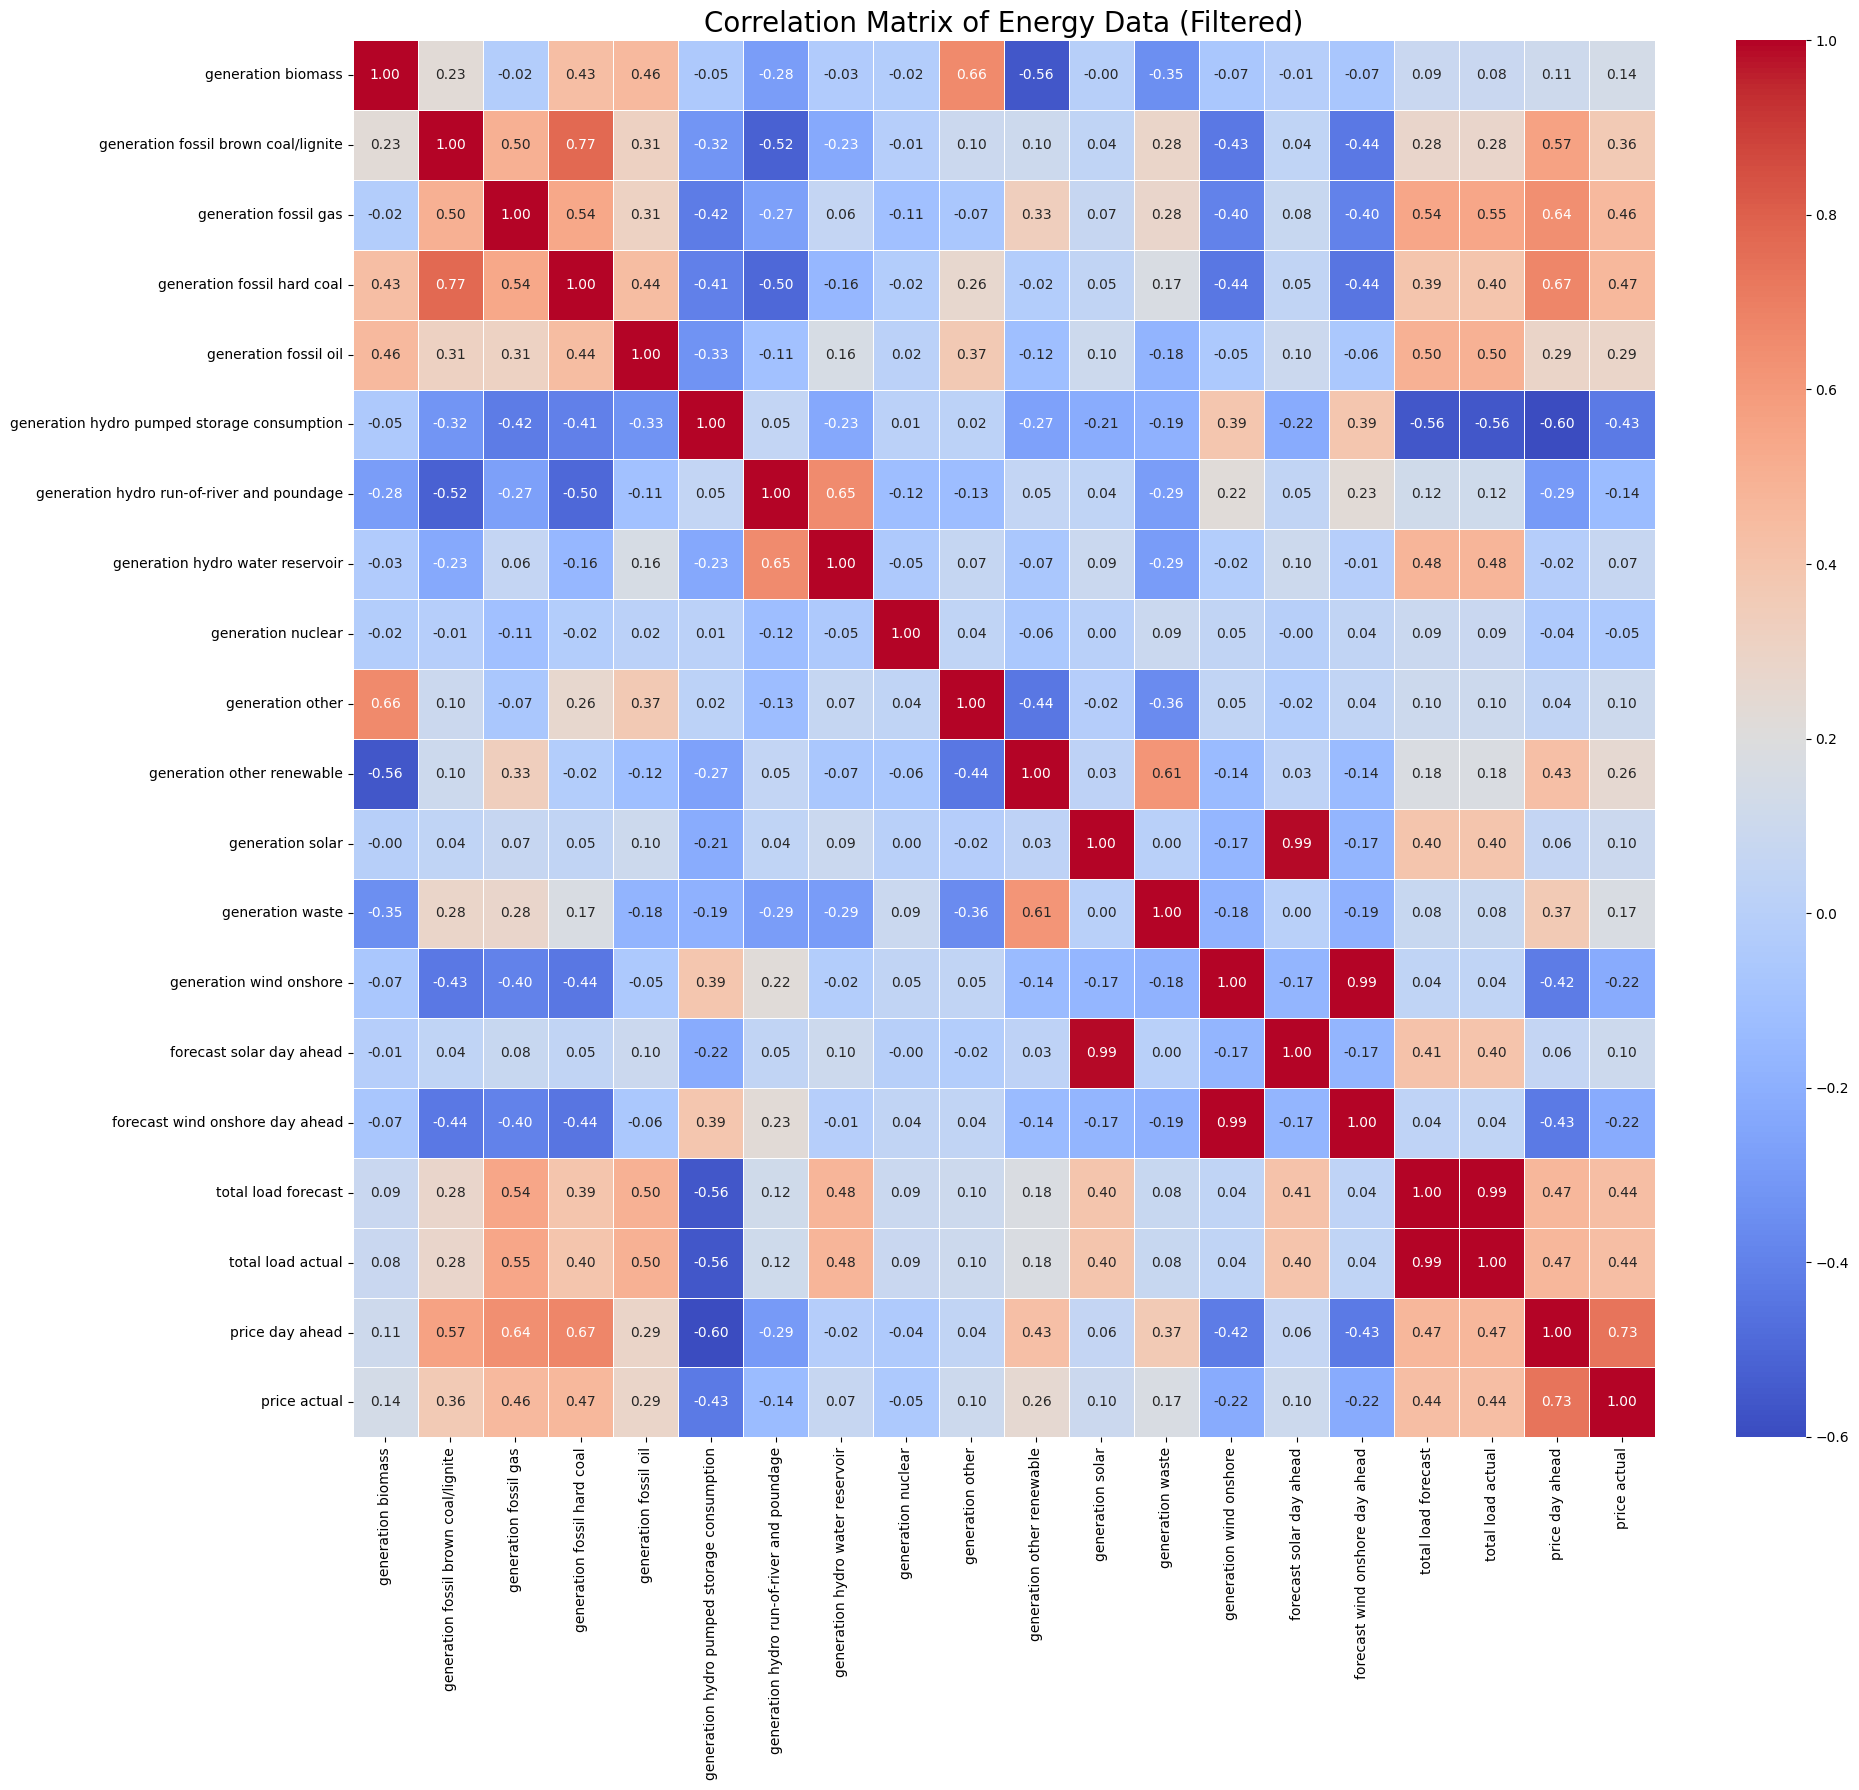

Correlation matrix heatmap for filtered numerical features generated.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['number'])

# Filter out columns with a mean of 0, as they won't contribute to correlation and can cause issues
# (e.g., 'generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation wind offshore' all have mean 0)
filtered_numerical_cols = numerical_cols.loc[:, (numerical_cols != 0).any(axis=0)]

# Compute the correlation matrix
correlation_matrix = filtered_numerical_cols.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Energy Data (Filtered)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Correlation matrix heatmap for filtered numerical features generated.")

## Visualize Weather Impact

### Subtask:
Analyze the impact of weather conditions by examining the relationship between weather-dependent energy generation (solar, wind) and total energy consumption using scatter plots.


**Reasoning**:
To analyze the impact of weather conditions, I will create two scatter plots to visualize the relationship between weather-dependent energy generation (solar and wind) and total energy consumption.



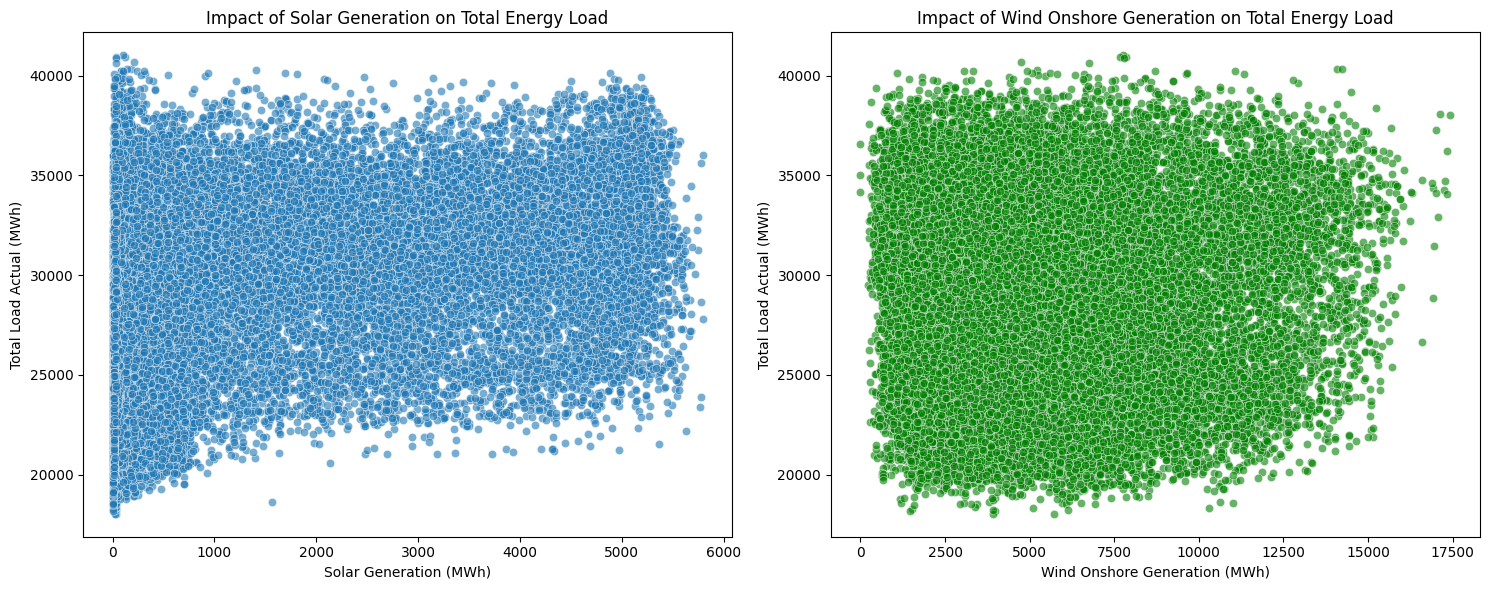

Scatter plots generated to visualize the impact of solar and wind generation on total energy load.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Scatter plot for Solar Generation vs. Total Load Actual
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='generation solar', y='total load actual', alpha=0.6)
plt.title('Impact of Solar Generation on Total Energy Load')
plt.xlabel('Solar Generation (MWh)')
plt.ylabel('Total Load Actual (MWh)')

# Scatter plot for Wind Onshore Generation vs. Total Load Actual
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='generation wind onshore', y='total load actual', alpha=0.6, color='green')
plt.title('Impact of Wind Onshore Generation on Total Energy Load')
plt.xlabel('Wind Onshore Generation (MWh)')
plt.ylabel('Total Load Actual (MWh)')

plt.tight_layout()
plt.show()

print("Scatter plots generated to visualize the impact of solar and wind generation on total energy load.")

## Final Task

### Subtask:
Summarize the key findings, patterns, and insights discovered during the Exploratory Data Analysis of the dataset.


## Summary:

### Data Analysis Key Findings

*   The dataset, comprising 35,064 entries and 29 columns, successfully loaded and provided data on energy generation, consumption, forecasts, and pricing in Spain.
*   Initial data inspection revealed two columns, `generation hydro pumped storage aggregated` and `forecast wind offshore eday ahead`, contained only missing values (35,064 each) and were subsequently removed. Other columns with minor missing values (17 to 36) were successfully imputed using a combination of forward and backward fill.
*   The `time` column was correctly converted to a datetime format, which is crucial for time-series analysis.
*   Descriptive statistics showed that certain energy generation categories, specifically `generation fossil coal-derived gas`, `generation fossil peat`, `generation geothermal`, and `generation marine`, recorded consistently zero output throughout the dataset, suggesting they might not be utilized or recorded as such.
*   Energy consumption (`total load actual`) exhibited a mean of approximately 28,697.6 MWh, with a substantial range from 18,041 MWh to 41,015 MWh.
*   Actual energy prices (`price actual`) displayed considerable variability, averaging around 57.88 \$/MWh and fluctuating between 9.33 \$/MWh and 116.80 \$/MWh.
*   Time-series visualizations were generated to illustrate trends in energy consumption, price, and key generation sources (fossil gas, wind onshore, solar, hydro water reservoir) over the dataset's period.
*   A heatmap of the correlation matrix for all numerical features was created, providing a visual overview of relationships within the energy data.
*   Scatter plots were used to visualize the relationships between `generation solar` and `total load actual`, and `generation wind onshore` and `total load actual`, to assess the impact of these weather-dependent energy sources on overall demand.

### Insights or Next Steps

*   Conduct more detailed time-series analysis, including decomposition, to further understand seasonal patterns, trends, and anomalies in energy consumption, generation, and pricing.
*   Investigate the specific high or low correlations observed in the heatmap to uncover actionable insights into interdependencies between different energy sources, consumption, and market prices.


# Task
Perform an Exploratory Data Analysis (EDA) on the "energy_dataset_spain.csv" file to understand energy consumption, generation, and pricing trends, and analyze the impact of weather conditions.

## Time Series Visualization of Energy Data

### Subtask:
Modify the existing line plots to increase visibility for the energy generation plot, specifically by enlarging the figure and placing the legend outside the plot area to avoid clutter from multiple generation source lines.


**Reasoning**:
To enhance the visibility of the energy generation plot and reduce clutter, I will modify the existing plotting code to increase the figure size and reposition the legend outside the plot area, as specified in the subtask instructions.



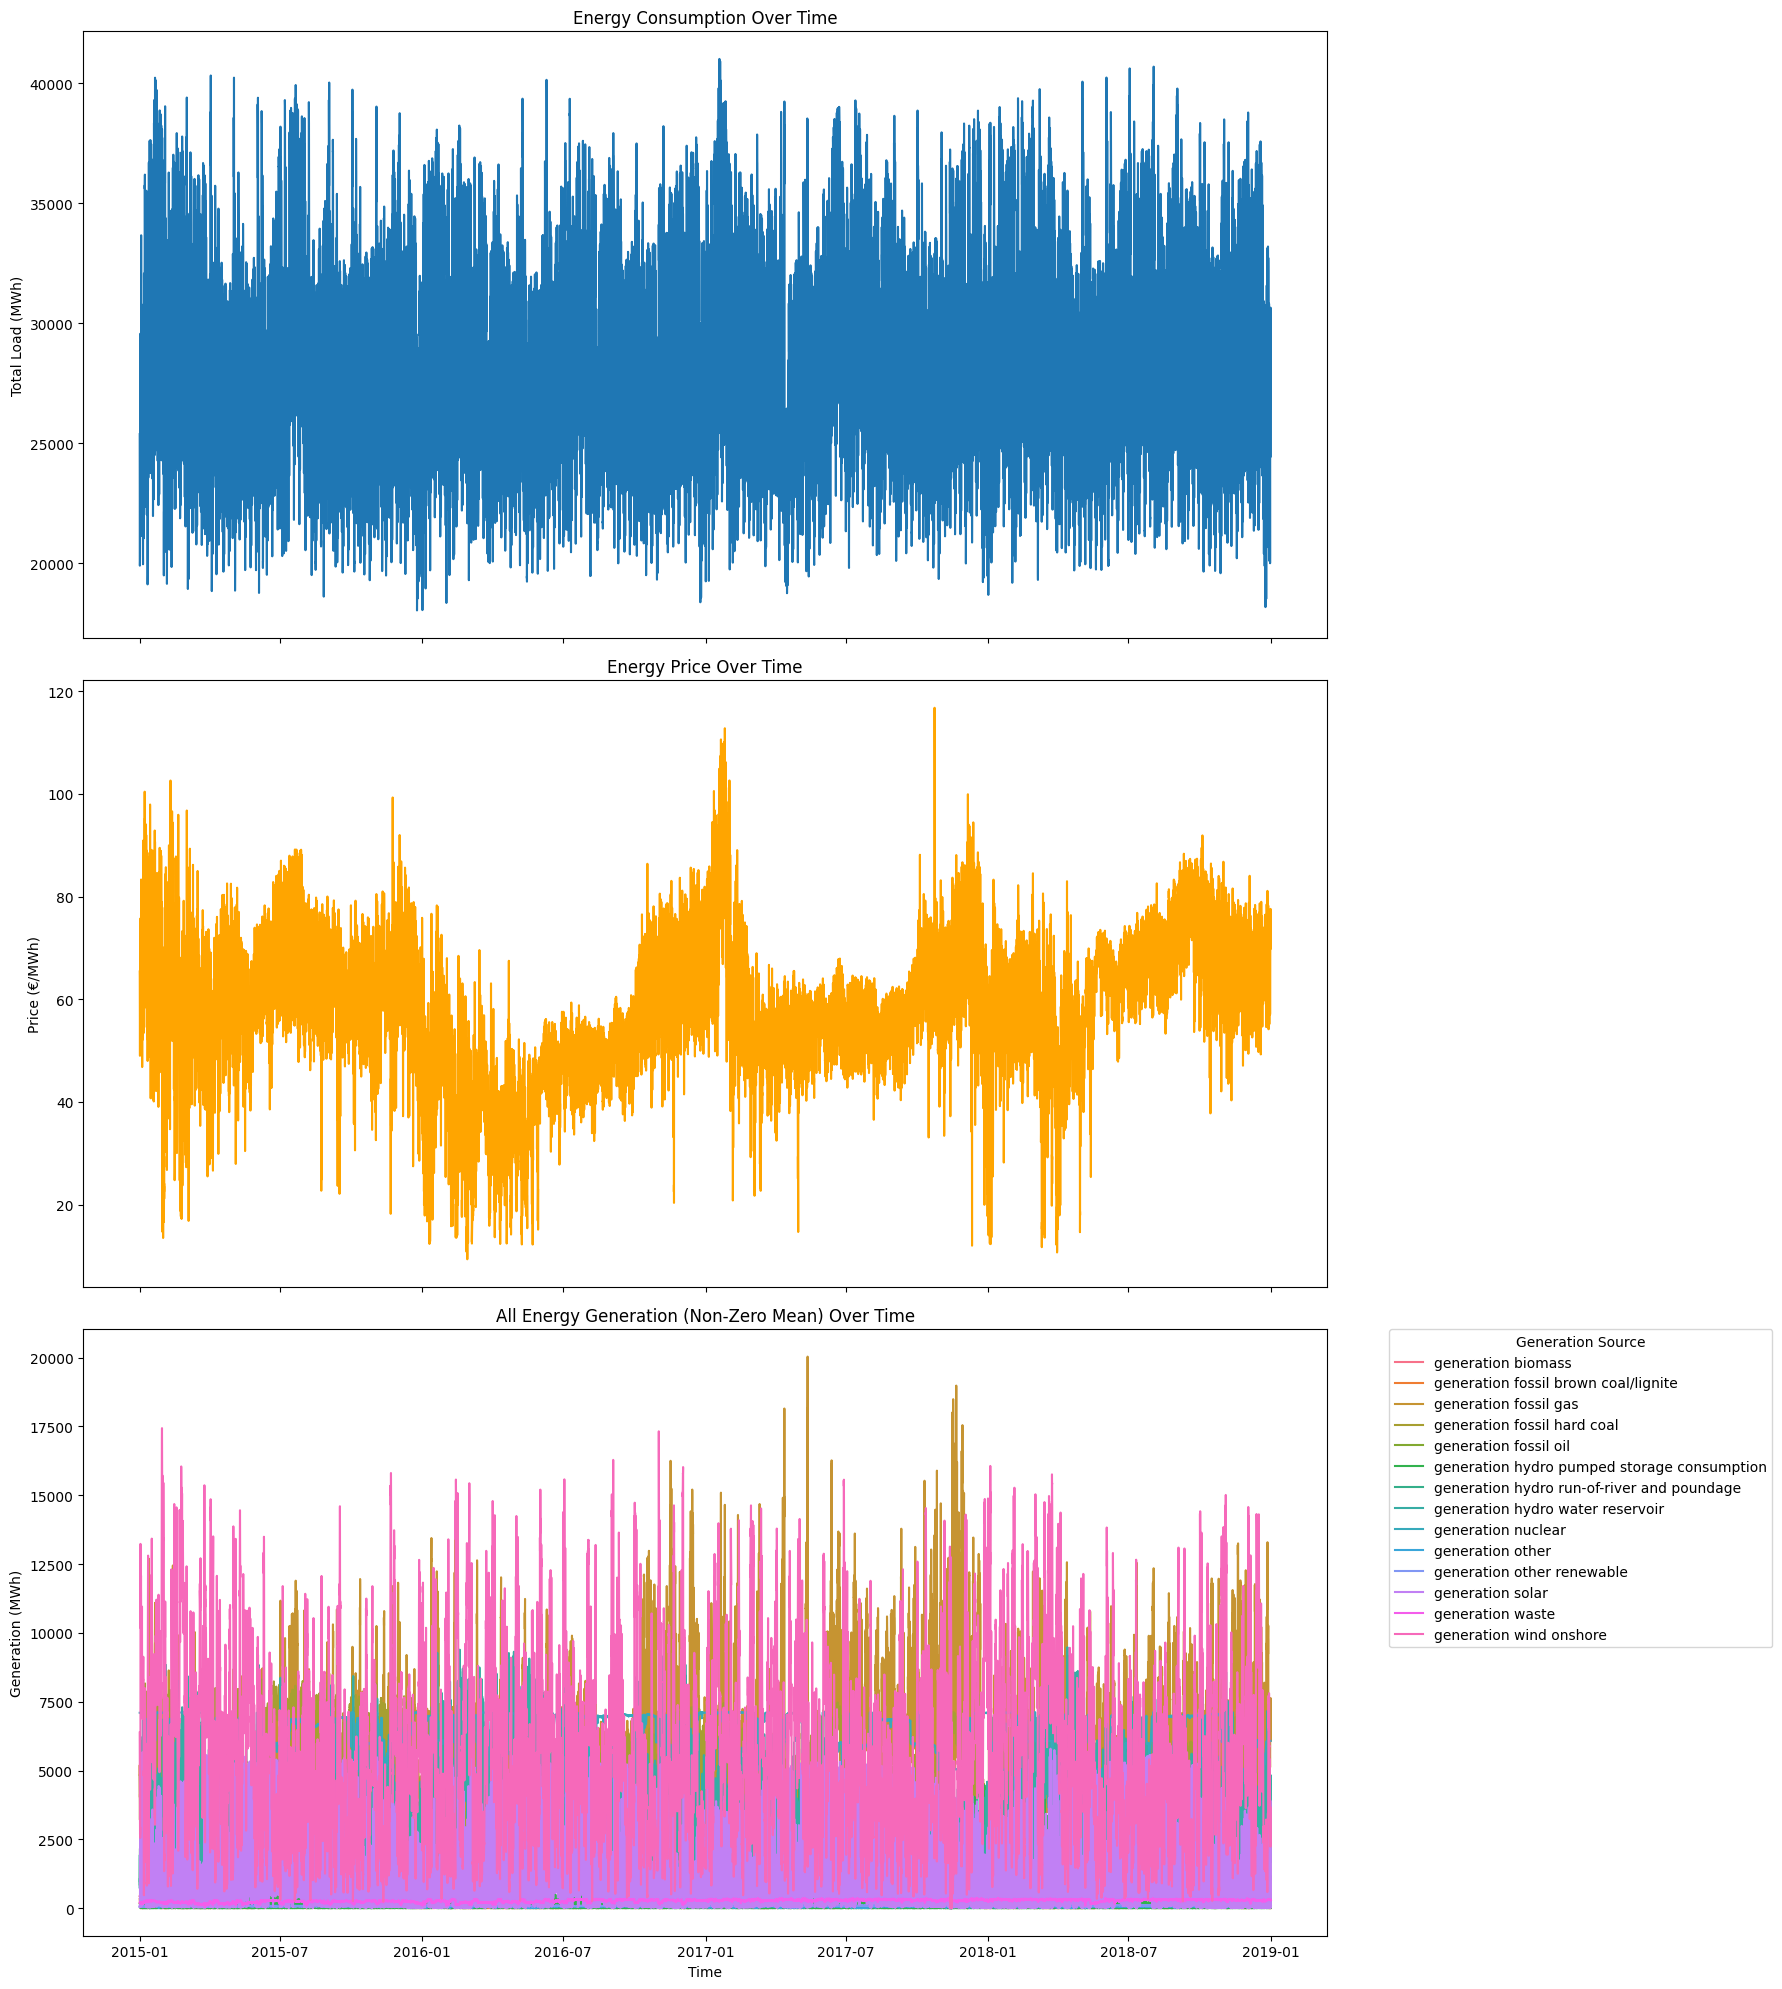

Generated line plots for energy consumption, price, and all non-zero mean generation sources with improved visibility.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the 'time' column as the DataFrame index
df_indexed = df.set_index('time')

# Create figure and axes for subplots, increasing the overall figure size
fig, axes = plt.subplots(3, 1, figsize=(18, 20), sharex=True)

# Plot 1: Energy Consumption Over Time
sns.lineplot(data=df_indexed, x=df_indexed.index, y='total load actual', ax=axes[0])
axes[0].set_title('Energy Consumption Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Total Load (MWh)')

# Plot 2: Energy Price Over Time
sns.lineplot(data=df_indexed, x=df_indexed.index, y='price actual', ax=axes[1], color='orange')
axes[1].set_title('Energy Price Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Price (€/MWh)')

# Plot 3: All Energy Generation with Non-Zero Mean Over Time
generation_columns = [col for col in df.columns if 'generation' in col and df[col].mean() != 0]
sns.lineplot(data=df_indexed[generation_columns], ax=axes[2], dashes=False)
axes[2].set_title('All Energy Generation (Non-Zero Mean) Over Time')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Generation (MWh)')
# Place the legend outside the plot area to avoid clutter
axes[2].legend(title='Generation Source', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

print("Generated line plots for energy consumption, price, and all non-zero mean generation sources with improved visibility.")

## Correlation Analysis

### Correlation matrix shows relevant numerical features (excluding those with a mean of 0) to understand relationships within the data.


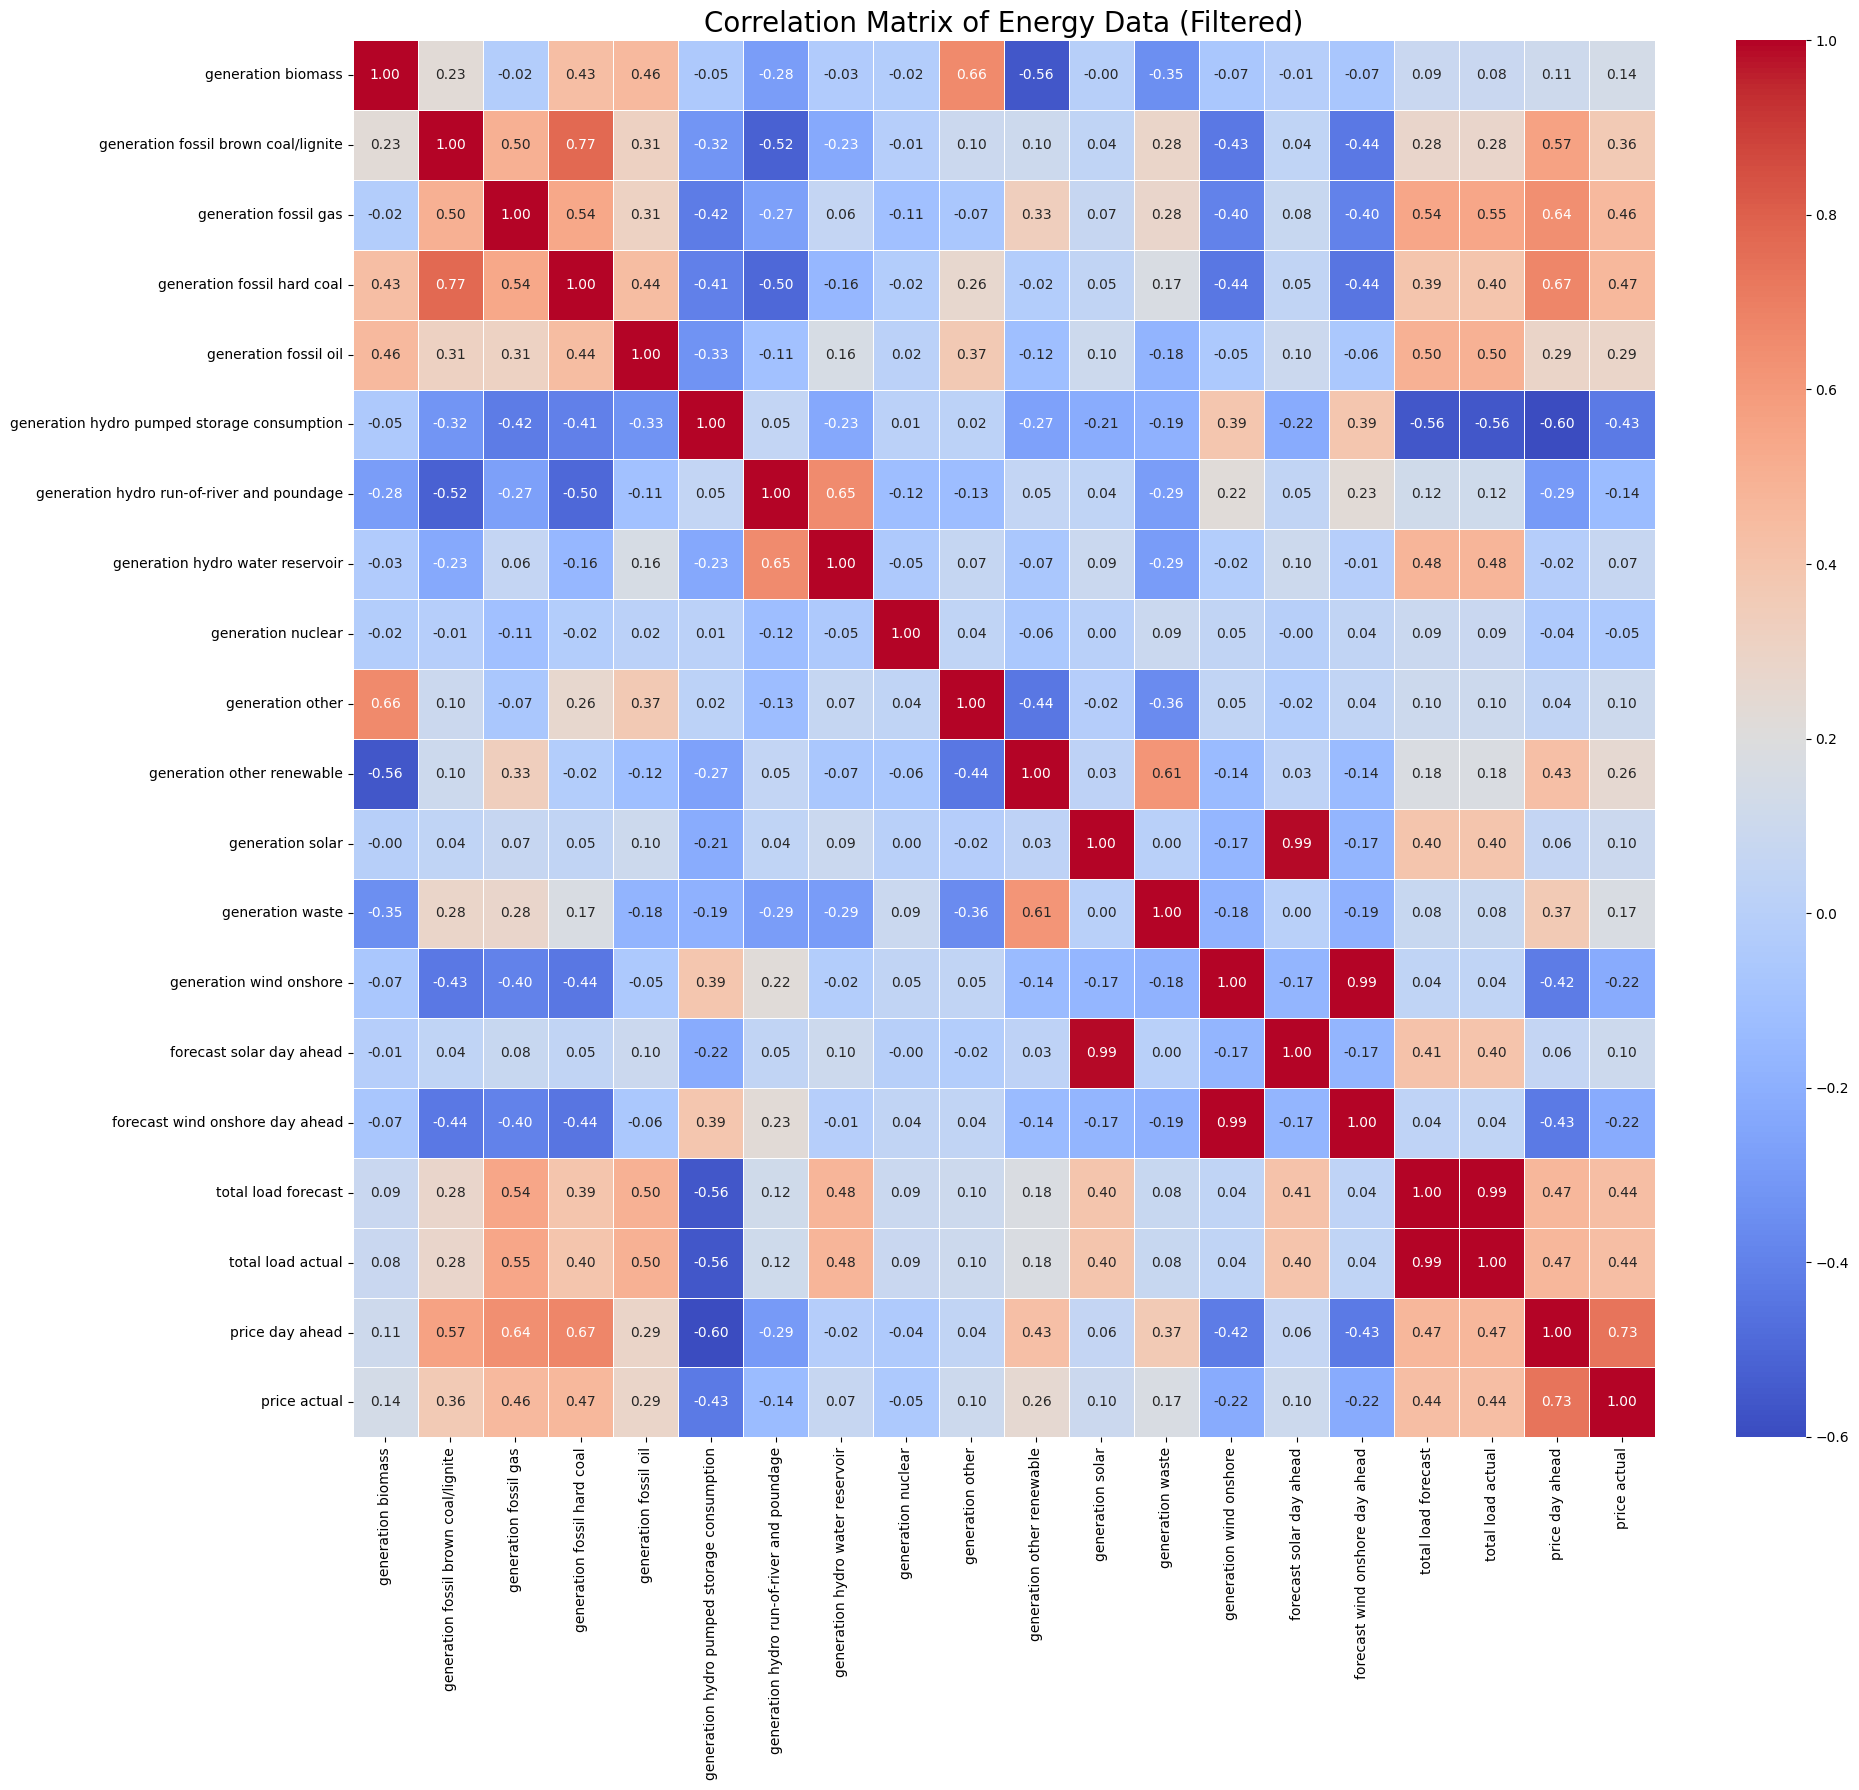

Correlation matrix heatmap for filtered numerical features generated.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=['number'])

# Filter out columns with a mean of 0, as they won't contribute to correlation and can cause issues
# (e.g., 'generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation wind offshore' all have mean 0)
filtered_numerical_cols = numerical_cols.loc[:, (numerical_cols != 0).any(axis=0)]

# Compute the correlation matrix
correlation_matrix = filtered_numerical_cols.corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Energy Data (Filtered)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Correlation matrix heatmap for filtered numerical features generated.")

## Visualize Weather Impact

### Examining the relationship between forecasted and actual weather-dependent energy generation (solar, wind) using scatter plots.


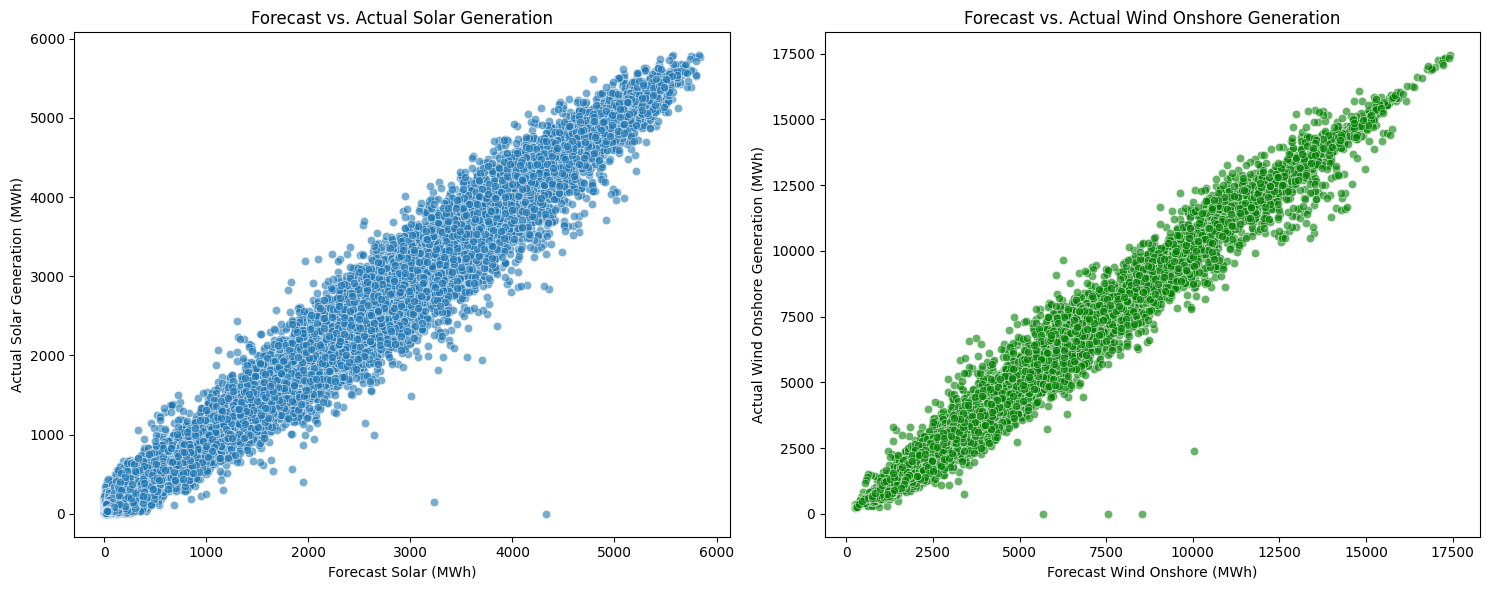

Scatter plots generated to visualize the relationship between forecasted and actual solar and wind generation.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Scatter plot for Forecast Solar vs. Actual Solar Generation
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='forecast solar day ahead', y='generation solar', alpha=0.6)
plt.title('Forecast vs. Actual Solar Generation')
plt.xlabel('Forecast Solar (MWh)')
plt.ylabel('Actual Solar Generation (MWh)')

# Scatter plot for Forecast Wind Onshore vs. Actual Wind Onshore Generation
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='forecast wind onshore day ahead', y='generation wind onshore', alpha=0.6, color='green')
plt.title('Forecast vs. Actual Wind Onshore Generation')
plt.xlabel('Forecast Wind Onshore (MWh)')
plt.ylabel('Actual Wind Onshore Generation (MWh)')

plt.tight_layout()
plt.show()

print("Scatter plots generated to visualize the relationship between forecasted and actual solar and wind generation.")